In [ ]:
from pathlib import Path
import json
from py_markdown_table.markdown_table import markdown_table
from numpy import load
from torch import from_numpy
from deepinv.utils.plotting import plot, plot_inset, preprocess_img
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon, ttest_rel

In [ ]:
# Knee acc 6
ids_knee = {
    "MC": "q12j539v",
    "SSDU": "ux7wfivh",
    "Noise2Inverse": "1u0zlfb5",
    "Weighted-SSDU": "c663rwjy",
    "VORTEX": "bm5al0qy",
    "EI": "w46f0xqe",
    "MOI": "lcmutynf",
    "MO-EI (ours)": "ech941px",#"dijz21sj" #diffeo-mo-ei
    "(Supervised)": "jqht7upm",
    "temp": "dijz21sj"
}
# Knee reproducing SSDU
ids_knee_ssdu = {
    "SSDU (7)": "kb4pbb73",
    "Noise2Inverse (7)": "wfv8fwiv",
}
# Knee ablation
ids_knee_abl = {
    "EI (diffeo)": "6m6wcca7",
    "MO-EI (rotate)": "3mzavwml",
}
# Brain-knee transfer
ids_brkn_trans = {
    "Supervised": "muibu6sy",
    "Self-sup": "e4kz25ki",
    "Interleaved": "8ielvaed"
}

# Brain acc 6
ids_brain = {
    "MC": "jnmp1fqt",
    "SSDU": "1g8s1p2m",
    "Noise2Inverse": "68we1xso",
    "Weighted-SSDU": "56osuotl",
    "Adversarial": "bo4m8jcq",
    "UAIR": "9ma7ndzl",
    "VORTEX": "8glarize",
    "EI": "oay0553s",
    "MOI": "12tm66pp",
    "MO-EI (ours)": "jbm1czk6", #"d6otk201", #diffeo-mo-ei
    "(Supervised)": "qmjy0ej1",
    "temp": "d6otk201"
}
# Brain reproducing SSDU
ids_brain_ssdu = {
    "SSDU (3)": "1g8s1p2m",
    "SSDU (7)": "wq0oh9fk",
    "Noise2Inverse (7)": "d9w3kn61",
    "Weighted-SSDU (3)": "56osuotl",
    "Weighted-SSDU (7)": "rmiq1ai4",
}
# Brain ablation
ids_brain_abl = {
    "MOI": "12tm66pp",
    "EI (rotate)": "oay0553s",
    "EI (diffeo)": "19wf0udg",
    "MO-EI (rotate)": "f0n546i7",
    "MO-EI (diffeo, ours)": "jbm1czk6",
}
ids_brain_unroll_iters = {
    "Weighted-SSDU (3)": "56osuotl",
    "Weighted-SSDU (5)": "",
    "Weighted-SSDU (7)": "rmiq1ai4",
    "Weighted-SSDU (9)": "",
    "MO-EI (ours) (3)": "jbm1czk6",
    "MO-EI (ours) (5)": "",
    "MO-EI (ours) (7)": "",
    "MO-EI (ours) (9)": "",
    "(Supervised) (3)": "qmjy0ej1",
    "(Supervised) (5)": "",
    "(Supervised) (7)": "",
    "(Supervised) (9)": "",
}
ids_brain_single = {
    ...
}
chosen = "brain"
ids = eval(f"ids_{chosen}")

Load results

In [3]:
filter_results = ("temp",)
filter_sample = ("MC", "Noise2Inverse", "EI (diffeo)", "MO-EI (rotate)", "VORTEX", "Adversarial", "UAIR", "SSDU")

In [9]:
results = {}
for title, id in ids.items():
    with open(f"models/paper/{id}/results.json", "r") as f:
        results[title] = json.load(f)
    if title not in filter_sample:
        results[title]["sample"] = load(f"models/paper/{id}/samples.npz")

In [10]:
def repr(m, dp=3, p='+'):
    return f"{m:.{dp}f}".lstrip('0') if (m is not None and m != "") else ""
#table = [{"name": "Zero-filled", "PSNR": repr(list(results.values())[0]["PSNR no learning"], 2), "SSIM": repr(list(results.values())[0]["SSIM no learning"], 4)} | {k: "" for k in ("PSNR2","PSNR3","SSIM2","SSIM3")}]
table = [
    {
        "name": k,
        "PSNR": repr(run["PSNR"], 2),
        "PSNR_std": repr(run["PSNR_std"], 2),
        "PSNR2": repr(run.get("PSNR2", ""), 2),
        "PSNR3": repr(run.get("PSNR3", ""), 2),
        "SSIM": repr(run["SSIM"], 4),
        "SSIM2": repr(run.get("SSIM2", ""), 4),
        "SSIM3": repr(run.get("SSIM3", ""), 4),
    } for k, run in results.items() if k not in filter_results
]
print(markdown_table(table).set_params(row_sep="markdown").get_markdown())

```|     name    | PSNR|PSNR_std|PSNR2|PSNR3| SSIM|SSIM2|SSIM3|
|-------------|-----|--------|-----|-----|-----|-----|-----|
|      MC     |27.66|  2.40  |     |     |.7861|     |     |
|     SSDU    |18.27|  1.01  |24.83|25.63|.4876|.6899|.7237|
|Noise2Inverse|18.49|  1.02  |23.84|26.30|.4693|.6573|.6685|
|Weighted-SSDU|29.12|  1.97  |29.04|30.40|.8054|.8079|.8101|
| Adversarial |18.52|   .31  |     |     |.4732|     |     |
|     UAIR    |14.00|  1.88  |     |     |.3715|     |     |
|    VORTEX   |27.75|  2.35  |     |     |.7898|     |     |
|      EI     |30.26|  2.61  |     |     |.8523|     |     |
|     MOI     |30.29|  2.88  |     |     |.8651|     |     |
| MO-EI (ours)|32.14|  2.73  |     |     |.8846|     |     |
| (Supervised)|33.15|  2.76  |     |     |.9032|     |     |```


In [11]:
for m in table:
    print(rf'{m["name"]} & {m["PSNR"]} & {m["SSIM"]} \\')

MC & 27.66 & .7861 \\
SSDU & 18.27 & .4876 \\
Noise2Inverse & 18.49 & .4693 \\
Weighted-SSDU & 29.12 & .8054 \\
Adversarial & 18.52 & .4732 \\
UAIR & 14.00 & .3715 \\
VORTEX & 27.75 & .7898 \\
EI & 30.26 & .8523 \\
MOI & 30.29 & .8651 \\
MO-EI (ours) & 32.14 & .8846 \\
(Supervised) & 33.15 & .9032 \\


In [12]:
for r in results.values():
    if "sample" in r and "x" in r["sample"]:
        x, x_init, y = from_numpy(r["sample"]["x"]), from_numpy(r["sample"]["x_init"]), from_numpy(r["sample"]["y"])
        break

plot_dict = {
    "Ground truth": x, 
    #"Mask": y != 0, 
    "Zero-filled": x_init
} | {
    k: from_numpy(results[k]["sample"]["x_hat"]) for k in results if k not in filter_sample + filter_results
}
labels = ["", repr(list(results.values())[0]["PSNR no learning"], 2)] + [repr(results[k]["PSNR"], 2) for k in results if k not in filter_sample + filter_results]
#plot(plot_dict, save_fn=f"models/paper/results_{chosen}.png", dpi=1200)

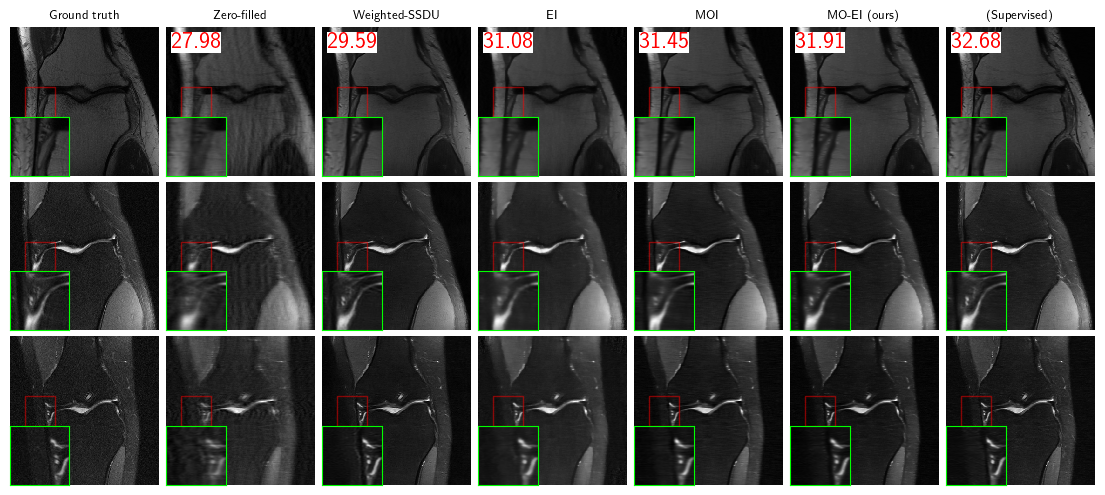

In [32]:
s = [0, 2, 5]#knee [5, 19]#brain_ssdu  [2, 5, 19]#brain [0,2]#brkn_trans 
plot_inset([preprocess_img(i)[s] for i in plot_dict.values()], titles=list(plot_dict.keys()), dpi=600, save_fn=f"models/paper/results_{chosen}.png", labels=labels,
    extract_loc=(0.1, 0.4), inset_loc=(0, 0.6) #knee
    #extract_loc=(0.35, 0.1), inset_loc=(0, 0.6) #brain
    #extract_loc=(0.4, 0.45), inset_loc=(0, 0.6) #brkn_trans
)

## Statistical significance of results

3.6488347930148316e-48 5.960432061424579e-17


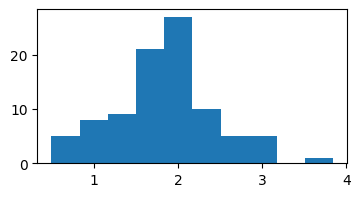

In [25]:
a = results["MO-EI (ours)"]["PSNR_vals"]
b = results["MOI"]["PSNR_vals"]
print(
    ttest_rel(a, b, alternative="greater").pvalue.tolist(),
    wilcoxon (a, b, alternative="greater").pvalue.tolist()
)
plt.figure(figsize=(4, 2))
_ = plt.hist([_a - _b for (_a, _b) in zip(a, b)])

## Plot diffeomorphisms

In [ ]:
import deepinv as dinv
brain_dataset = dinv.datasets.SimpleFastMRISliceDataset("data", "brain", download=True)
xb = brain_dataset[0].unsqueeze(0)
d = dinv.transform.CPABDiffeomorphism(n_tesselation=2)
def crop(x, i=64):
    return x[...,i:-i,i:-i]
dinv.utils.plot([crop(xb), crop(d(xb)), x, d(x)], titles=["$\mathbf{x}$","$\mathbf{T}_g\mathbf{x}$","$\mathbf{x}$","$\mathbf{T}_g\mathbf{x}$"], dpi=600, save_fn="models/paper/transforms.png")